In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [5]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

pima = pd.read_csv("pima-indians-diabetes.csv", names=cols)


In [6]:
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Training : 80%

Testing : 20%

Xây dựng mô hình và kết quả

In [7]:
X = pima[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
          'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]

y = pima['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2021
)

In [8]:
NB = GaussianNB()

NB.fit(X_train, y_train)
print("Training accuracy: {:.2f}" .format(NB.score(X_train, y_train)))

y_predict = NB.predict(X_test)
print("Testing accuracy NB : {:.2f}".format(NB.score(X_test, y_test)))


Training accuracy: 0.77
Testing accuracy NB : 0.77


Sau khi huấn luyện, mô hình đạt accuracy = 93%

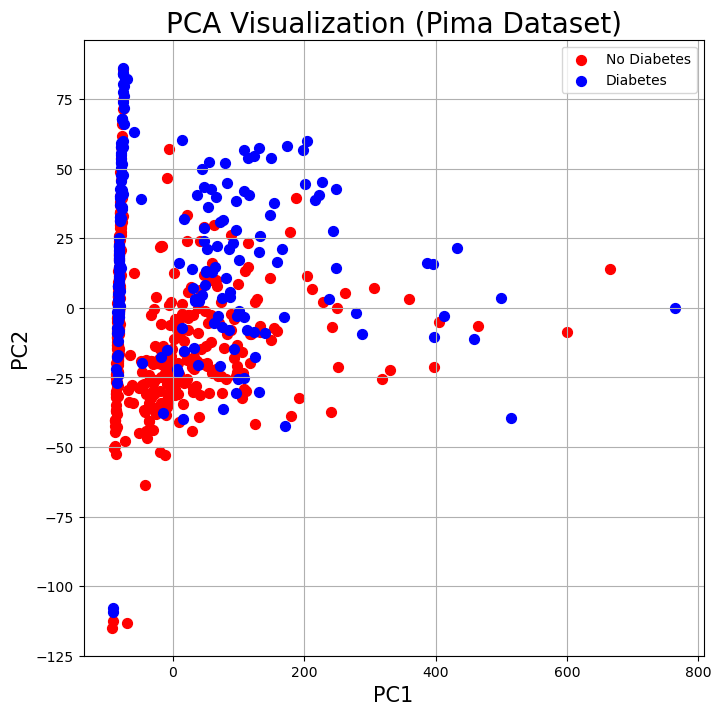

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Giảm chiều
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_train)

principalDf = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

# Ghép với label
finalDf = pd.concat([principalDf, y_train.reset_index(drop=True)], axis=1)

# Vẽ
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel('PC1', fontsize=15)
ax.set_ylabel('PC2', fontsize=15)
ax.set_title('PCA Visualization (Pima Dataset)', fontsize=20)

# ✔️ chỉ 2 lớp
targets = [0, 1]
targets_2_desc = {0: 'No Diabetes', 1: 'Diabetes'}
colors = ['r', 'b']

for target, color in zip(targets, colors):
    indicesToKeep = finalDf['Outcome'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'PC1'],
               finalDf.loc[indicesToKeep, 'PC2'],
               c=color,
               s=50,
               label=targets_2_desc[target])

ax.legend()
ax.grid()
plt.show()